# Umami vs. beacon: does the new counter agree with the old one?

The `analytics` hit counter (`POST /hit`) has been live for a few days. This notebook
compares it against a fresh Umami export covering the same window, to answer one
question: **is the beacon actually collecting what Umami collected?**

Two things make this comparison narrower than "the whole export":

- `rollup/{site}/{YYYY-MM}.json` for the current month may already hold days backfilled
  from the *original* Umami migration (`03_umami_backfill.ipynb`) — those are old data,
  not a live measurement, and comparing them against a fresh export would just be Umami
  against itself. Every stored day carries a `source` (`"umami"` or `"beacon"`), so this
  notebook uses that instead of guessing from dates.
- The beacon side reads two layers, mirroring `analytics/buckets.ts`: the monthly rollup
  first, then a 24-hourly-bucket fallback for any day the weekly compaction cron hasn't
  reached yet — recent days live only in `counts/` until then.

In [1]:
import os
from collections import Counter
from datetime import date, timedelta

import matplotlib.pyplot as plt
import pandas as pd
from dotenv import load_dotenv
from matplotlib.ticker import MaxNLocator

from storage import S3Storage
from umami_backfill import read_pageviews

load_dotenv()  # searches upward — finds ../.env (analytics/.env)

SITE = "fretchen.eu"
UMAMI_CSV = "export/umami_recent.csv"

storage = S3Storage(
    access_key=os.environ["SCW_ACCESS_KEY"],
    secret_key=os.environ["SCW_SECRET_KEY"],
)

## Umami side

Reuses `umami_backfill.read_pageviews` as-is — it already filters to pageviews on the
production hostname and normalises paths to the beacon's canonical form (locale stripped,
trailing slash), so a day's count here is directly comparable to a beacon day's count.

In [2]:
pageviews = read_pageviews(UMAMI_CSV)
umami_by_day = Counter(day for day, _path in pageviews)

all_days = sorted(umami_by_day)
print(f"{len(pageviews)} pageviews, {all_days[0]} .. {all_days[-1]}")

187 pageviews, 2026-08-01 .. 2026-08-15


## Beacon side

Same two-layer read `GET /stats` does — rollup first, hourly fallback for anything not
compacted yet — reimplemented here rather than imported, since the original is TypeScript.
An old backfilled day keeps whatever `source` it was stored with, so it can never be
mistaken for a live measurement just because it happens to fall in this date range.

In [3]:
def read_beacon_range(storage, site: str, days: list[str]) -> dict[str, dict]:
    """day -> {"hits": int, "pages": dict, "source": "beacon" | "umami" | "none"}.

    Mirrors analytics/buckets.ts's collectRange: the monthly rollup first (kept as-is,
    whatever source it carries), then a computed-key 24-hour fallback — never a listed
    prefix — for any day not yet compacted by the weekly rollup cron.
    """
    rollups: dict[str, dict] = {}
    result: dict[str, dict] = {}

    for day in days:
        month = day[:7]
        if month not in rollups:
            rollups[month] = storage.read(f"rollup/{site}/{month}.json") or {"days": {}}

        entry = rollups[month]["days"].get(day)
        if entry is not None:
            result[day] = entry
            continue

        hours = [storage.read(f"counts/{site}/{day}T{h:02d}.json") for h in range(24)]
        present = [h for h in hours if h is not None]
        if not present:
            result[day] = {"hits": 0, "pages": {}, "source": "none"}
            continue

        pages: dict[str, int] = {}
        for h in present:
            for path, count in h.get("pages", {}).items():
                pages[path] = pages.get(path, 0) + count
        result[day] = {
            "hits": sum(h.get("hits", 0) for h in present),
            "pages": pages,
            "source": "beacon",
        }

    return result

In [4]:
def days_between(from_day: str, to_day: str) -> list[str]:
    d0, d1 = date.fromisoformat(from_day), date.fromisoformat(to_day)
    return [(d0 + timedelta(days=i)).isoformat() for i in range((d1 - d0).days + 1)]


window = days_between(all_days[0], all_days[-1])
beacon_by_day = read_beacon_range(storage, SITE, window)

## Side by side

`comparable` (`True`) marks a day the beacon itself actually measured. Everything else is
excluded from totals for one of two different reasons, kept distinguishable via
`beacon_source`: `"umami"` means the old backfill still owns that day (comparing it would
just be Umami against itself); `"none"` means the beacon has *zero* data — worth knowing
about, not the same thing as "not applicable".

In [5]:
df = pd.DataFrame(
    [
        {
            "day": day,
            "umami_hits": umami_by_day.get(day, 0),
            "beacon_hits": beacon_by_day[day]["hits"],
            "beacon_source": beacon_by_day[day]["source"],
            "comparable": beacon_by_day[day]["source"] == "beacon",
        }
        for day in window
    ]
).set_index("day")

df

,umami_hits,beacon_hits,beacon_source,comparable
day,,,,
2026-08-01,8,8,umami,False
2026-08-02,6,6,umami,False
2026-08-03,7,7,umami,False
2026-08-04,3,3,umami,False
2026-08-05,9,9,umami,False
2026-08-06,2,2,umami,False
2026-08-07,4,4,umami,False
2026-08-08,56,56,umami,False
2026-08-09,39,39,umami,False


In [6]:
# "Since the beacon went live" = every day not still owned by the old Umami backfill —
# that includes real beacon measurements AND the zero-hit gap where nothing was recorded
# at all. Excluding umami-sourced days here (not just filtering to comparable=True) is
# what lets the gap check below actually see an outage instead of filtering it away first.
since_beacon = df[df["beacon_source"] != "umami"]
backfilled = df[df["beacon_source"] == "umami"]

comparable = df[df["comparable"]]
span = f"{comparable.index.min()} .. {comparable.index.max()}"
print(f"Comparable window: {span}  ({len(comparable)} of {len(since_beacon)} days since go-live)")
print(f"Umami total (comparable days):   {comparable['umami_hits'].sum()}")
print(f"Beacon total (comparable days):  {comparable['beacon_hits'].sum()}")

gaps = since_beacon[(since_beacon["umami_hits"] > 0) & (since_beacon["beacon_hits"] == 0)]
if len(gaps):
    print("\nDays with Umami traffic but ZERO beacon hits — the beacon likely wasn't")
    print("running (e.g. a broken deploy), not a genuinely quiet day:")
    print(gaps[["umami_hits", "beacon_hits"]])
else:
    print("\nNo days with Umami traffic and zero beacon hits.")

if len(backfilled):
    print(
        f"\nStill owned by the old backfill ({len(backfilled)} days) — comparing these"
        " would just be Umami against itself:"
    )
    print(backfilled[["umami_hits", "beacon_source"]])

Comparable window: 2026-08-11 .. 2026-08-15  (3 of 5 days since go-live)
Umami total (comparable days):   44
Beacon total (comparable days):  54

Days with Umami traffic but ZERO beacon hits — the beacon likely wasn't
running (e.g. a broken deploy), not a genuinely quiet day:
            umami_hits  beacon_hits
day                                
2026-08-12           2            0
2026-08-13           3            0

Still owned by the old backfill (10 days) — comparing these would just be Umami against itself:
            umami_hits beacon_source
day                                 
2026-08-01           8         umami
2026-08-02           6         umami
2026-08-03           7         umami
2026-08-04           3         umami
2026-08-05           9         umami
2026-08-06           2         umami
2026-08-07           4         umami
2026-08-08          56         umami
2026-08-09          39         umami
2026-08-10           4         umami


## Chart

Two categorical series (Umami, beacon) in a fixed order — validated colours, not defaults:
`node scripts/validate_palette.js "#2a78d6,#eb6834" --mode light` passes every check
(worst adjacent CVD ΔE 24.7, normal-vision ΔE 33.6 — both well clear of the ΔE ≥ 8 / ≥ 15
targets). Plots every day since the beacon went live, including the zero-hit gap days —
an outage should read as a visible dent between real bars, not vanish because it failed
the "comparable" filter.

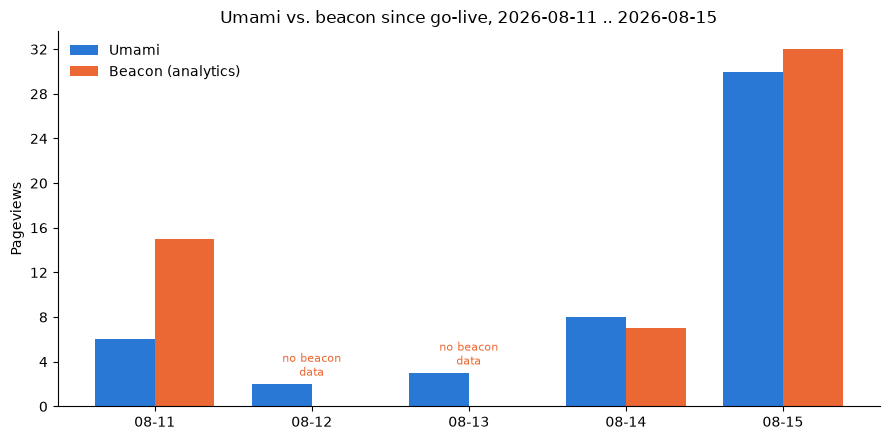

In [7]:
UMAMI_COLOR = "#2a78d6"  # validated categorical slot 1 (blue)
BEACON_COLOR = "#eb6834"  # validated categorical slot 2 (orange)

x = range(len(since_beacon))
width = 0.38

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(
    [i - width / 2 for i in x], since_beacon["umami_hits"], width, label="Umami", color=UMAMI_COLOR
)
ax.bar(
    [i + width / 2 for i in x],
    since_beacon["beacon_hits"],
    width,
    label="Beacon (analytics)",
    color=BEACON_COLOR,
)

ax.set_xticks(list(x))
ax.set_xticklabels([d[5:] for d in since_beacon.index])  # MM-DD
ax.set_ylabel("Pageviews")
ax.set_title(
    f"Umami vs. beacon since go-live, {since_beacon.index.min()} .. {since_beacon.index.max()}"
)
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False)

for i, (umami_hits, beacon_hits) in enumerate(
    zip(since_beacon["umami_hits"], since_beacon["beacon_hits"])
):
    if umami_hits > 0 and beacon_hits == 0:
        ax.annotate(
            "no beacon\ndata",
            (i, umami_hits),
            textcoords="offset points",
            xytext=(0, 6),
            ha="center",
            fontsize=8,
            color=BEACON_COLOR,
        )

fig.tight_layout()
plt.show()